In [22]:
import seaborn as sns
import pandas as pd
import os
import matplotlib.pyplot as plt
import glob
import sklearn.metrics as sk
import pingouin as pg

Compute ICC(2,1) for children

In [23]:
mdfsDF = pd.read_csv('/vol/tensusers2/wharmsen/edLing-RDR/subjectiveFluency/child/mdfsDF.tsv', sep='\t')

# Add total oral reading fluency score & ICC
sumList = []
for unique_rater in set(mdfsDF['rater']):
    for unique_filename in set(mdfsDF['file']):
        sumScore = mdfsDF[(mdfsDF['file'] == unique_filename) & (mdfsDF['rater'] == unique_rater)]['value'].sum()/4
        sumList.append([unique_filename, 'sumScore', sumScore, unique_rater])    
mdfsSumDF = pd.DataFrame(sumList, columns = ['file', 'variable', 'value', 'rater'])

mdfsTotalDF = pd.concat([mdfsDF, mdfsSumDF])

icc = pg.intraclass_corr(data=mdfsTotalDF[mdfsTotalDF['variable'] == 'sumScore'], targets='file', raters='rater', ratings='value')
icc.set_index('Type')

,Description,ICC,F,df1,df2,pval,CI95%
Type,,,,,,,
ICC1,Single raters absolute,0.659992,6.823322,70,142,2.672666e-22,"[0.55, 0.76]"
ICC2,Single random raters,0.662450,7.291764,70,140,1.783031e-23,"[0.55, 0.76]"
ICC3,Single fixed raters,0.677133,7.291764,70,140,1.783031e-23,"[0.57, 0.77]"
ICC1k,Average raters absolute,0.853444,6.823322,70,142,2.672666e-22,"[0.78, 0.9]"
ICC2k,Average random raters,0.854811,7.291764,70,140,1.783031e-23,"[0.78, 0.91]"
ICC3k,Average fixed raters,0.862859,7.291764,70,140,1.783031e-23,"[0.8, 0.91]"


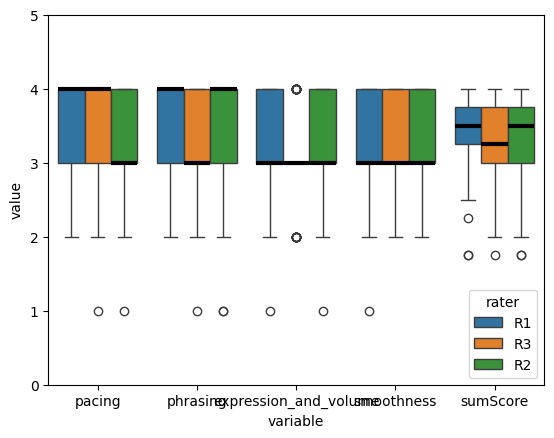

In [24]:
sns.boxplot(mdfsTotalDF, x='variable', y='value', hue='rater', medianprops={'color': 'black', 'lw': 3}) #'ls': ':'
plt.yticks([0,1,2,3,4,5])
plt.savefig('')

Compute ICC(2,1) for adults

In [26]:
mdfsDF = pd.read_csv('/vol/tensusers2/wharmsen/edLing-RDR/subjectiveFluency/adult/mdfsDF.tsv', sep='\t')

# Add total oral reading fluency score & ICC
sumList = []
for unique_rater in set(mdfsDF['rater']):
    for unique_filename in set(mdfsDF['file']):
        sumScore = mdfsDF[(mdfsDF['file'] == unique_filename) & (mdfsDF['rater'] == unique_rater)]['value'].sum()/4
        sumList.append([unique_filename, 'sumScore', sumScore, unique_rater])    
mdfsSumDF = pd.DataFrame(sumList, columns = ['file', 'variable', 'value', 'rater'])

mdfsTotalDF = pd.concat([mdfsDF, mdfsSumDF])

icc = pg.intraclass_corr(data=mdfsTotalDF[mdfsTotalDF['variable'] == 'sumScore'], targets='file', raters='rater', ratings='value')
icc.set_index('Type')

,Description,ICC,F,df1,df2,pval,CI95%
Type,,,,,,,
ICC1,Single raters absolute,0.187726,1.693333,15,32,0.103403,"[-0.09, 0.54]"
ICC2,Single random raters,0.218750,1.984375,15,30,0.053751,"[-0.04, 0.55]"
ICC3,Single fixed raters,0.247059,1.984375,15,30,0.053751,"[-0.05, 0.59]"
ICC1k,Average raters absolute,0.409449,1.693333,15,32,0.103403,"[-0.34, 0.78]"
ICC2k,Average random raters,0.456522,1.984375,15,30,0.053751,"[-0.13, 0.78]"
ICC3k,Average fixed raters,0.496063,1.984375,15,30,0.053751,"[-0.16, 0.81]"


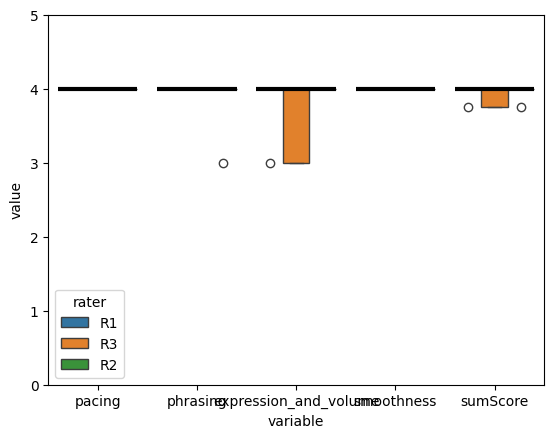

In [27]:
sns.boxplot(mdfsTotalDF, x='variable', y='value', hue='rater', medianprops={'color': 'black', 'lw': 3}) #'ls': ':'
plt.yticks([0,1,2,3,4,5])
plt.savefig('')